# 🧠🤖 Classificadores MLP - Doenças em Raio-X do Tórax

Nesta tarefa, você irá utilizar a base de dados [Chest X-ray Image (COVID19, PNEUMONIA, and NORMAL) disponível no kaggle](https://www.kaggle.com/datasets/alsaniipe/chest-x-ray-image) que contém exames de raio-x de pacientes saudáveis, com pneumonia e com covid19. O objetivo  é treinar uma rede neural capaz de identificar se o raio-x pertence a uma pessoa saudável ou com uma das duas doenças.


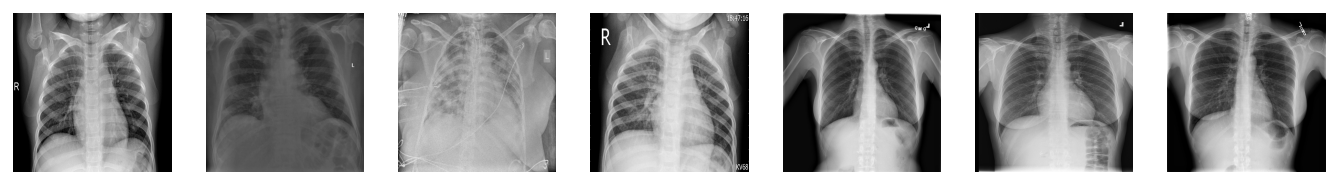

Use o notebook de classificação de doenças em plantas como base para implementar este notebook. Siga os passos indicados abaixo. 

‼️**Importante** ‼️ : Este dataset é substancialmente maior que o de doenças em folhas de feijão e possivelmente será bem demorado rodar os testes. Para que não demore tanto, reduza as imagens para um tamanho pequeno como $64 \times 64$, use modelos com menores parâmetros e use um subconjunto das amostras.

- Faça o download do dataset usando a biblioteca `kagglehub`. 


In [1]:
from tkinter import Image

# resposta
import kagglehub

ds_path = kagglehub.dataset_download("alsaniipe/chest-x-ray-image")
ds_path

/home/Heitor-Guerra/IdeaProjects/Redes_Neurais/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'/home/Heitor-Guerra/.cache/kagglehub/datasets/alsaniipe/chest-x-ray-image/versions/1'


- Crie uma classe para representar o dataset ou utilizar o tipo pré-definido `ImageFolder` definido em `torchvision.datasets` que lê dados organizados em pastas e constrói dataset do torch. Veja [instruções de como esta classe neste blog post](https://medium.com/@vineethrajesh2/loading-in-your-own-image-datasets-in-pytorch-9e4064171074). 


In [2]:
# resposta
import torch
import os
import numpy as np
import torchvision.transforms as transforms

# # Using ImageFolder
from torchvision.datasets import ImageFolder

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.PILToTensor(),
    transforms.ConvertImageDtype(torch.float32)
])
train_ds = ImageFolder(os.path.join(ds_path, "Data/train"), transform)
test_ds = ImageFolder(os.path.join(ds_path, "Data/test"), transform)



# # Creating Class Dataset
# from torch.utils.data import Dataset
# from PIL import Image
# train_path = os.path.join(ds_path, "Data/train")
# test_path = os.path.join(ds_path, "Data/test")
#
# class LungDataset(Dataset):
#     def __init__(self, path):
#         self._data = []
#         self._labels = []
#         for label, subdir in enumerate(["COVID19", "NORMAL", "PNEUMONIA"]):
#             dir = os.path.join(path, subdir)
#             for file in os.listdir(dir):
#                 self._data.append(os.path.join(dir, file))
#                 self._labels.append(label)
#
#         self._transform = transforms.Compose([
#             transforms.Resize((64,64)),
#             transforms.PILToTensor(),
#             transforms.ConvertImageDtype(torch.float32)
#         ])
#
#     def __len__(self):
#         return len(self._data)
#     def __getitem__(self, idx):
#         img = self._data[idx]
#         label = torch.tensor(self._labels[idx])
#         img = Image.open(img).convert("RGB")
#         img = self._transform(img)
#         return img, label
#
# train_ds = LungDataset(train_path)
# test_ds = LungDataset(test_path)

- Visualize algumas imagens para ganhar intimidade com os dados.


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

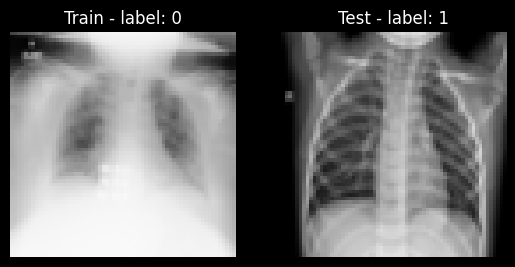

In [3]:
# resposta
import matplotlib.pyplot as plt

# imagem do conjunto de treino
plt.subplot(1, 2, 1)
img_tensor, label = train_ds[1]
img = img_tensor.permute(1, 2, 0)
plt.imshow(img)
plt.title(f'Train - label: {label}')
plt.grid(False)
plt.axis('off')

# imagem do conjunto de teste
plt.subplot(1, 2, 2)
img_tensor, label = test_ds[200]
img = img_tensor.permute(1, 2, 0)
plt.imshow(img)
plt.title(f'Test - label: {label}')
plt.grid(False)
plt.axis('off')


- Crie dataloaders para os conjuntos de treino e teste.


In [4]:
# resposta
from torch.utils.data import DataLoader, Dataset

batch_size = 64
shuffle = True


train_loader = DataLoader(train_ds, batch_size, shuffle)
test_loader = DataLoader(test_ds, batch_size, shuffle)



- Defina o modelo.


In [5]:
# resposta
import torch.nn as nn

n_classes = 3
n_hidden = 128
n_ins = 64*64*3
learning_rate = 1e-4

net = nn.Sequential(
    nn.Flatten(),

    nn.Linear(n_ins, n_hidden),
    nn.ReLU(),

    nn.Linear(n_hidden, n_hidden),
    nn.ReLU(),

    nn.Linear(n_hidden, n_classes),
)

net

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=12288, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=3, bias=True)
)

- Crie a função de perda.


In [7]:
# resposta

criterion = nn.CrossEntropyLoss()


- Crie um otimizador.

In [8]:
# resposta
import torch.optim as optim

optimizer = optim.Adam(net.parameters(), lr=learning_rate)

- Use as funções `train_loop` e `eval_loop` para treinar o modelo. 

In [9]:
# resposta
import numpy as np

def train_loop(train_loader, net):
    all_preds = []
    all_labels = []

    # itera sobre todos os batches do dataloader
    for batch in train_loader:
        # separa entadas e saídas do batch; data é uma lista contendo [inputs, labels]
        imgs, labels = batch
        # zero the parameter gradients
        optimizer.zero_grad()
        # forward
        outputs = net(imgs)
        # calcula loss
        loss = criterion(outputs, labels)
        # calcula gradientes
        loss.backward()
        # atualiza parâmetros com descida do gradiente
        optimizer.step()

        # recupera as classes preditas pelo modelo como sendo aquelas
        # com maior logits ("probabilidade" antes do softmax)
        pred_classes = np.argmax(outputs.detach().numpy(), axis=-1)

        # salva classes preditas e verdadeiras em suas respectivas listas
        all_preds.extend(list(pred_classes))
        all_labels.extend(labels)

    return all_labels, all_preds


In [10]:
def eval_loop(loader, net):
    all_preds = []
    all_labels = []

    # inicie um bloco no_grad dado que não precisamos calcular gradientes durante a avaliação
    with torch.no_grad():
        # itera sobre os batches de teste
        for batch in loader:
            # separa imagens e labels
            imgs, labels = batch
            # passa imagens pela rede neural para obter predições
            outputs = net(imgs)
            # obtém as classes como aquelas com maior valor na última camada
            outputs = np.argmax(outputs.numpy(), axis=-1)

            # adicione classes verdadeiras e preditas nas respectivas listas
            all_labels.extend(labels)
            all_preds.extend(list(outputs))

    return all_labels, all_preds


In [11]:
# Loop
from sklearn.metrics import accuracy_score

n_epochs = 10
history = []

for epoch in range(n_epochs):  # loop over the dataset multiple times
    true, pred = train_loop(train_loader, net)
    train_acc = accuracy_score(true, pred)

    true, pred = eval_loop(test_loader, net)
    test_acc = accuracy_score(true, pred)

    history.append([train_acc, test_acc])
    print(f"Epoch {epoch} Train acc: {train_acc:.2f} Test acc: {test_acc:.2f} ")



Epoch 0 Train acc: 0.71 Test acc: 0.89 
Epoch 1 Train acc: 0.86 Test acc: 0.91 
Epoch 2 Train acc: 0.89 Test acc: 0.92 
Epoch 3 Train acc: 0.90 Test acc: 0.92 
Epoch 4 Train acc: 0.91 Test acc: 0.92 
Epoch 5 Train acc: 0.91 Test acc: 0.92 
Epoch 6 Train acc: 0.91 Test acc: 0.92 
Epoch 7 Train acc: 0.91 Test acc: 0.93 
Epoch 8 Train acc: 0.91 Test acc: 0.94 
Epoch 9 Train acc: 0.92 Test acc: 0.94 


- Plote as curvas de evolução da perda ou da acurácia para os conjuntos de treino e teste. Avalie se aconteceu underfitting, overfitting ou se o treinamento ocorreu de forma saudável. Ajuste os hiperparâmetros para melhorar a performance.

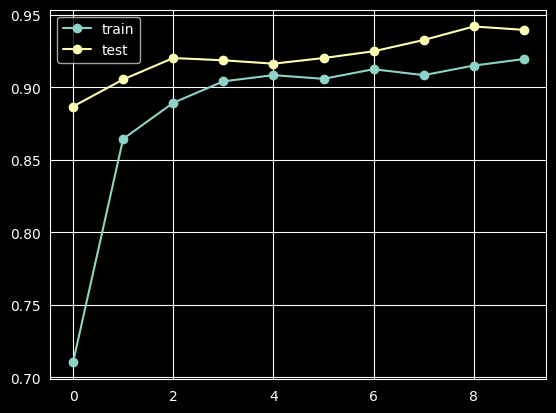

In [12]:
# resposta
history = np.array(history)

plt.plot(history[:, 0], '-o')
plt.plot(history[:, 1], '-o')
plt.legend(['train', 'test'])



- Mostre o `classification_report`  para o conjunto de teste e analise os resultados estão satisfatórios. 

In [13]:
# resposta
from sklearn.metrics import classification_report

true, pred = eval_loop(test_loader, net)

print(classification_report(true, pred));


              precision    recall  f1-score   support

           0       0.94      0.89      0.92       116
           1       0.92      0.87      0.89       317
           2       0.95      0.97      0.96       855

    accuracy                           0.94      1288
   macro avg       0.94      0.91      0.92      1288
weighted avg       0.94      0.94      0.94      1288



- Faça uma análise qualitativa de algumas imagens de exemplo.

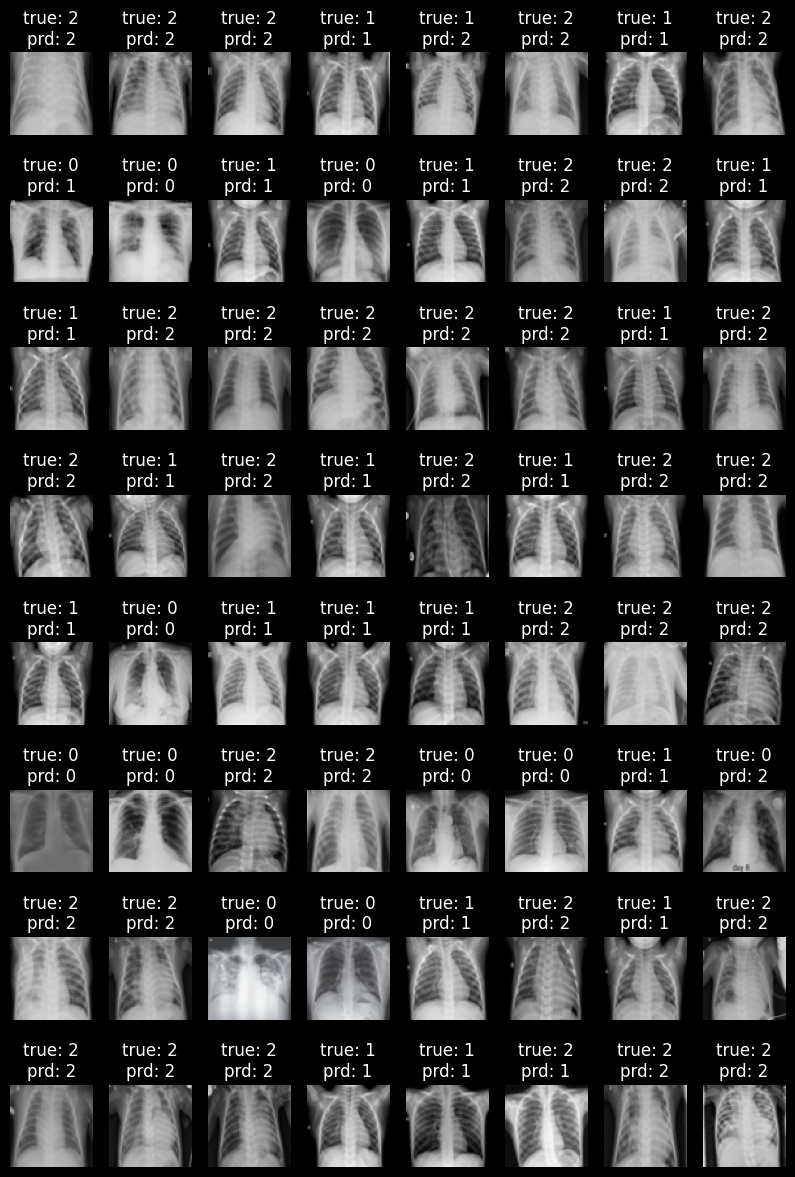

In [14]:
# resposta
# seleciona um batch de teste
dataiter = iter(test_loader)
images, labels = next(dataiter)

# passa as imagens pela rede
with torch.no_grad():
    prd = net(images).numpy()

# obtém as classes preditas
prd = np.argmax(prd, axis=-1)

# mostra as imagens e as respectivas classes preditas e reais
plt.close("all")
plt.figure(figsize=(10, 15))

n = len(images)
grid_size = int(np.ceil(np.sqrt(n)))
for idx in range(n):
    plt.subplot(grid_size, grid_size, idx + 1)
    img = images[idx].numpy()
    # muda do formato [channels, rows, cols] do torch para [rows, cols, channels]
    img = np.transpose(img, (1, 2, 0))
    plt.imshow(img)
    plt.grid(False)
    plt.axis("off")
    title = f"true: {labels[idx].numpy()}"
    title += f"\nprd: {prd[idx]}"
    plt.title(title)
